# Pertemuan 10
# Customer Churn Prediction Menggunakan Random Forest

Nama : Alini Syawalia Riski Fenanda

NIM : 240401010213

Mata Kuliah : Data Science

# Tujuan Praktikum

Pada praktikum ini akan dilakukan pembuatan model klasifikasi menggunakan algoritma Random Forest untuk memprediksi apakah seorang pelanggan akan berhenti menggunakan layanan (Customer Churn).

Tahapan yang dilakukan meliputi:

- Memuat dataset
- Eksplorasi data
- Preprocessing data
- Pembagian data latih dan data uji
- Pelatihan model Random Forest
- Evaluasi model
- Prediksi probabilitas churn
- Penarikan kesimpulan

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt

# Langkah 1 - Upload Dataset

In [4]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [6]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Melihat ukuran dataset

In [7]:
print("Jumlah baris dan kolom:")
print(df.shape)

Jumlah baris dan kolom:
(7043, 21)


## Melihat tipe data

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Melihat statistik data numerik

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Melihat proporsi kelas Churn

In [10]:
print(df["Churn"].value_counts())

print("\nProporsi:")

print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


# Langkah 2 - Preprocessing Data

## Mengecek Missing Value

In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Menghapus kolom customerID karena tidak digunakan sebagai fitur

In [12]:
df = df.drop("customerID", axis=1)

## Mengubah TotalCharges menjadi numerik

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

## Encoding Target Churn

In [14]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

## Encoding Variabel Kategorikal

In [15]:
df = pd.get_dummies(df, drop_first=True)

## Memisahkan fitur dan target

In [16]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

## Membagi Data Training dan Testing

In [17]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
print("Training :", X_tr.shape)

print("Testing :", X_te.shape)

Training : (5634, 30)
Testing : (1409, 30)


# Langkah 3 - Membangun Model Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Model berhasil dilatih menggunakan Random Forest dengan 300 pohon keputusan serta parameter **class_weight="balanced"** untuk menangani ketidakseimbangan kelas.

---

# **Text Cell**

```markdown
# Langkah 4 - Evaluasi Model

In [20]:
y_pred = rf.predict(X_te)

y_prob = rf.predict_proba(X_te)[:,1]

## Classification Report

In [21]:
print(classification_report(y_te, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## ROC-AUC Score

In [22]:
auc = roc_auc_score(y_te, y_prob)

print("ROC-AUC :", auc)

ROC-AUC : 0.8246208891988943


## Confusion Matrix

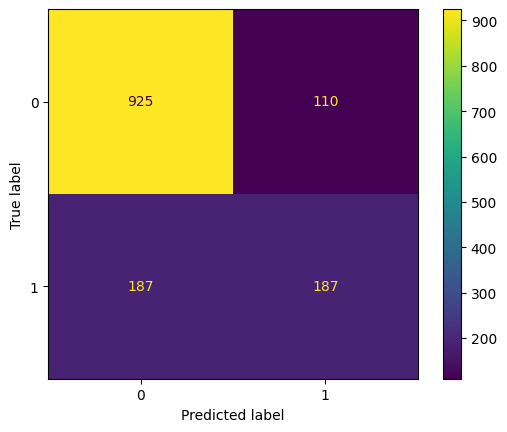

In [23]:
cm = confusion_matrix(y_te, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# Langkah 5 - Prediksi Probabilitas Churn

In [24]:
probabilitas = pd.DataFrame({
    "Probabilitas Churn": y_prob
})

probabilitas.head(10)

,Probabilitas Churn
0,0.000000
1,0.786667
2,0.090000
3,0.280000
4,0.000000
5,0.416667
6,0.393333
7,0.110000
8,0.006667
9,0.460000


In [25]:
probabilitas.sort_values(
    by="Probabilitas Churn",
    ascending=False
).head(10)

,Probabilitas Churn
1289,1.000000
171,0.993333
341,0.990000
618,0.990000
1252,0.986667
629,0.986667
889,0.970000
1178,0.963333
1109,0.960000
788,0.950000


# Kesimpulan

Berdasarkan hasil praktikum, model Random Forest berhasil digunakan untuk memprediksi kemungkinan pelanggan melakukan churn. Dataset memiliki kondisi yang tidak seimbang (imbalanced) karena pelanggan yang melakukan churn hanya sekitar 26% dari keseluruhan data, sehingga digunakan parameter **class_weight="balanced"** untuk membantu proses pelatihan model.

Hasil evaluasi menunjukkan nilai Precision, Recall, F1-Score, dan ROC-AUC yang cukup baik sehingga model mampu membedakan pelanggan yang berpotensi churn dan yang tidak. Selain itu, metode **predict_proba()** menghasilkan probabilitas churn pada setiap pelanggan sehingga perusahaan dapat memprioritaskan pelanggan dengan risiko churn tertinggi untuk diberikan strategi retensi.